# BNS vs BHNS: GRB Population Comparison

Side-by-side comparison of GRB class fractions and formation efficiencies for Binary Neutron Stars (BNS) and Black Hole – Neutron Star (BHNS) mergers.

Uses results from `GRB_BNS.ipynb` (Model A, fiducial) and `GRB_BHNS.ipynb` (Model A, BH spin a=0.5).

Run `GRB_BNS.ipynb` and `GRB_BHNS.ipynb` first to generate the `.npy` export files, or run those notebooks to have the variables in memory.

## 1. Load Saved Efficiency Arrays

In [18]:
import numpy as np
import matplotlib.pyplot as plt

metallicityGrid = [0.0001, 0.00011, 0.00012, 0.00014, 0.00016, 0.00017,
                   0.00019, 0.00022, 0.00024, 0.00027, 0.0003,  0.00034,
                   0.00037, 0.00042, 0.00047, 0.00052, 0.00058, 0.00065,
                   0.00073, 0.00081, 0.0009,  0.00101, 0.00113, 0.00126,
                   0.0014,  0.00157, 0.00175, 0.00195, 0.00218, 0.00243,
                   0.00272, 0.00303, 0.00339, 0.00378, 0.00422, 0.00471,
                   0.00526, 0.00587, 0.00655, 0.00732, 0.00817, 0.00912,
                   0.01018, 0.01137, 0.01269, 0.01416, 0.01581, 0.01765,
                   0.01971, 0.022,   0.0244,  0.02705, 0.03]

bns  = np.load('/Users/josephrodriguez/research visualization/results/eff_BNS.npy')
bhns = np.load('/Users/josephrodriguez/research visualization/results/eff_BHNS.npy')

eff_total_BNS,  eff_short_BNS,  eff_long_BNS   = bns
eff_total_BHNS, eff_long_BHNS_a05              = bhns

print('BNS  - total efficiency range:',
      f'{eff_total_BNS[eff_total_BNS>0].min():.2e} – {eff_total_BNS.max():.2e}')
print('BHNS - total efficiency range:',
      f'{eff_total_BHNS[eff_total_BHNS>0].min():.2e} – {eff_total_BHNS.max():.2e}')

BNS  - total efficiency range: 4.79e-07 – 4.37e-06
BHNS - total efficiency range: 3.95e-10 – 1.21e-05


## 2. GRB Class Fractions: BNS vs BHNS

Fraction of all merging systems in each GRB class. BHNS fractions are for assumed BH spin `a = 0.5`.

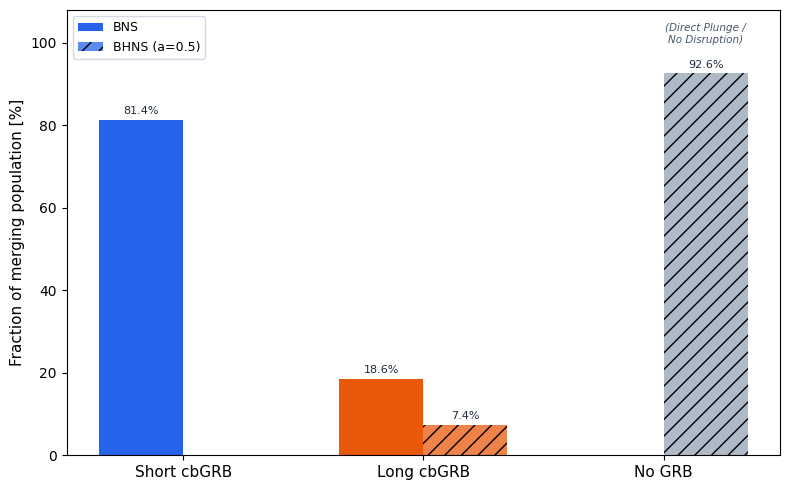

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

labels    = ['Short cbGRB', 'Long cbGRB', 'No GRB']
bns_frac  = [81.4, 18.6, 0.0]
bhns_frac = [0.0,  7.4,  92.6]  # a=0.5
colors    = ['#2563EB', '#EA580C', '#94A3B8']

x = np.arange(len(labels))
w = 0.35

bars_bns  = ax.bar(x - w/2, bns_frac,  w, color=colors, label='BNS')
bars_bhns = ax.bar(x + w/2, bhns_frac, w, color=colors, alpha=0.75,
                   hatch='//', label='BHNS (a=0.5)')

# Quantitative labels above each bar
for bar in bars_bns:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8, color='#1E293B')

for bar in bars_bhns:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8, color='#1E293B')

# Physics annotation above the BHNS 'No GRB' bar (index 2, right bar)
ax.text(x[2] + w/2, bhns_frac[2] + 7.0,
        '(Direct Plunge /\nNo Disruption)', ha='center', va='bottom',
        fontsize=7.5, color='#475569', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Fraction of merging population [%]', fontsize=11)
ax.set_ylim(0, 108)
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#CBD5E1')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/comparison_grb_fractions.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 3. Formation Efficiency vs Metallicity

BNS (blue) and BHNS (orange) formation efficiency per solar mass of star-forming material, broken down by GRB class.

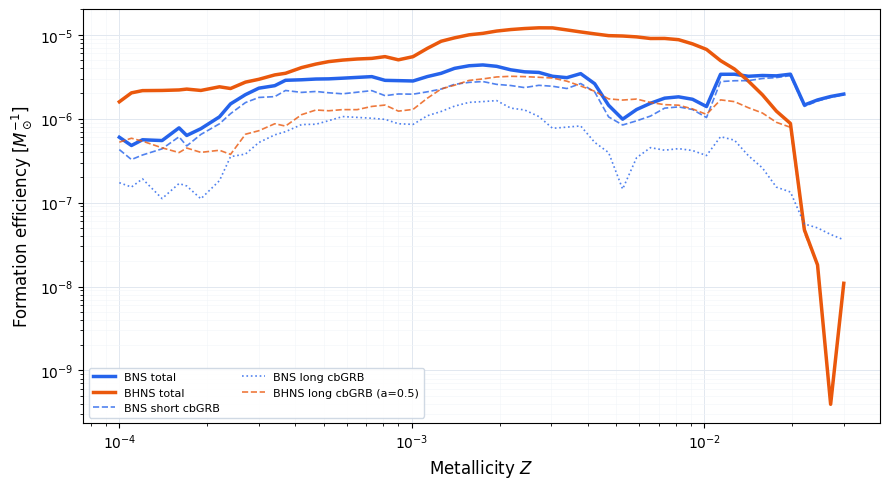

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))

# Total lines — heroes of the plot (lw=2.5)
ax.plot(metallicityGrid, eff_total_BNS,    color='#2563EB', lw=2.5,
        label='BNS total')
ax.plot(metallicityGrid, eff_total_BHNS,   color='#EA580C', lw=2.5,
        label='BHNS total')

# Sub-population lines — supporting detail (lw=1.2, alpha=0.8)
ax.plot(metallicityGrid, eff_short_BNS,     color='#2563EB', lw=1.2, ls='--',
        alpha=0.8, label='BNS short cbGRB')
ax.plot(metallicityGrid, eff_long_BNS,      color='#2563EB', lw=1.2, ls=':',
        alpha=0.8, label='BNS long cbGRB')
ax.plot(metallicityGrid, eff_long_BHNS_a05, color='#EA580C', lw=1.2, ls='--',
        alpha=0.8, label='BHNS long cbGRB (a=0.5)')

# Subtle grid — major and minor ticks
ax.grid(which='major', color='#E2E8F0', linewidth=0.7, linestyle='-')
ax.grid(which='minor', color='#F1F5F9', linewidth=0.4, linestyle='-')
ax.set_axisbelow(True)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Metallicity $Z$', fontsize=12)
ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$', fontsize=12)
ax.legend(fontsize=8, ncol=2, framealpha=0.9, edgecolor='#CBD5E1',
          loc='lower left')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/comparison_efficiency.png',
            dpi=150, bbox_inches='tight')
plt.show()
